# 02 · Image Preprocessing

Demonstrates and justifies the preprocessing pipeline in `src/data/preprocessing.py`:

1. Step-by-step pipeline on one image
2. Before / after for every stage
3. Parameter choices (CLAHE clip limit, Ben Graham sigma, denoising filter)
4. Effect on the worst-quality (darkest) images
5. Quantitative quality measures before and after preprocessing

Needs the dataset and the split CSVs from `01_eda.ipynb`. Figures go to `outputs/figures/`.

In [1]:
import os, sys
from pathlib import Path
ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT))
if Path("/kaggle/input").exists() and "DR_DATA_ROOT" not in os.environ:
    hits = [p.parent for p in Path("/kaggle/input").rglob("No_DR") if p.is_dir()]
    if hits:
        os.environ["DR_DATA_ROOT"] = str(hits[0].parent)

import copy
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from src.data import preprocessing as pp
from src.utils.config import load_config
from src.utils.seed import set_seed

cfg = load_config(ROOT / "configs" / "config.yaml")
set_seed(cfg["seed"])
P, CLASS_NAMES = cfg["paths"], cfg["data"]["class_names"]
FIG = P["figures_dir"]; FIG.mkdir(parents=True, exist_ok=True)
sns.set_theme(style="white")

# Use the training split only, so nothing here is tuned on validation or test images.
train = pd.read_csv(P["splits_dir"] / "train.csv", dtype={"patient_id": str})
load = lambda rel: pp.load_image(P["data_root"] / rel)
print(len(train), "training images")

24588 training images


## 1. Pipeline step by step

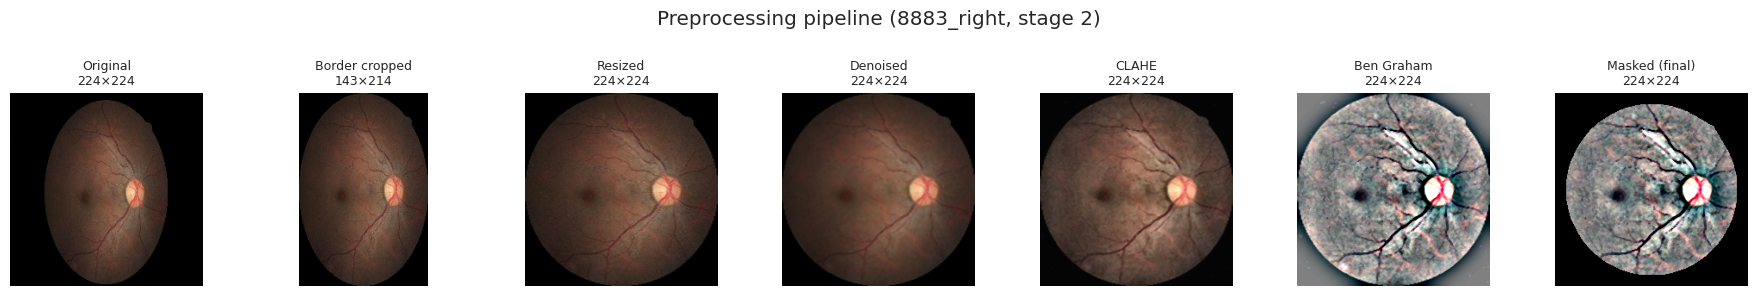

In [2]:
example = train[train["label"] == 2].sample(1, random_state=cfg["seed"]).iloc[0]
steps = pp.preprocess_steps(load(example["path"]), cfg)

fig, axes = plt.subplots(1, len(steps), figsize=(2.6 * len(steps), 3))
for ax, (name, im) in zip(axes, steps.items()):
    ax.imshow(im); ax.set_title(f"{name}\n{im.shape[1]}×{im.shape[0]}", fontsize=9); ax.axis("off")
plt.suptitle(f"Preprocessing pipeline ({example['image_id']}, stage {example['label']})")
plt.tight_layout(); plt.savefig(FIG / "preprocessing_steps.png", dpi=200, bbox_inches="tight"); plt.show()

## 2. Before and after for each stage

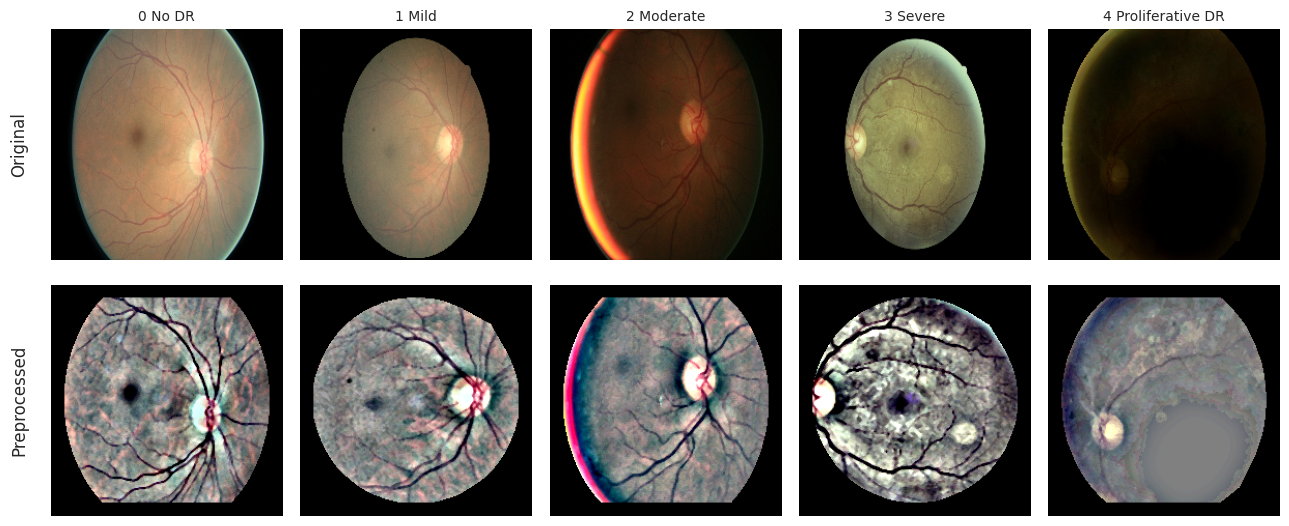

In [3]:
per_stage = train.groupby("label").sample(1, random_state=cfg["seed"]).sort_values("label")
fig, axes = plt.subplots(2, 5, figsize=(13, 5.6))
for j, (_, r) in enumerate(per_stage.iterrows()):
    img = load(r["path"])
    axes[0, j].imshow(img); axes[0, j].set_title(f"{r['label']} {CLASS_NAMES[r['label']]}", fontsize=10)
    axes[1, j].imshow(pp.preprocess(img, cfg))
    for ax in axes[:, j]: ax.axis("off")
axes[0, 0].text(-0.1, 0.5, "Original", transform=axes[0, 0].transAxes, rotation=90, va="center", ha="right")
axes[1, 0].text(-0.1, 0.5, "Preprocessed", transform=axes[1, 0].transAxes, rotation=90, va="center", ha="right")
plt.tight_layout(); plt.savefig(FIG / "preprocessing_per_stage.png", dpi=200, bbox_inches="tight"); plt.show()

## 3. Parameter choices

- **CLAHE clip limit**: too low has little effect, too high amplifies noise. 2.0 is the balance.
- **Ben Graham sigma**: small sigma keeps only tiny detail, large sigma keeps lighting variation. 10 suits 224px images.
- **Denoising**: median vs bilateral on a zoomed crop.

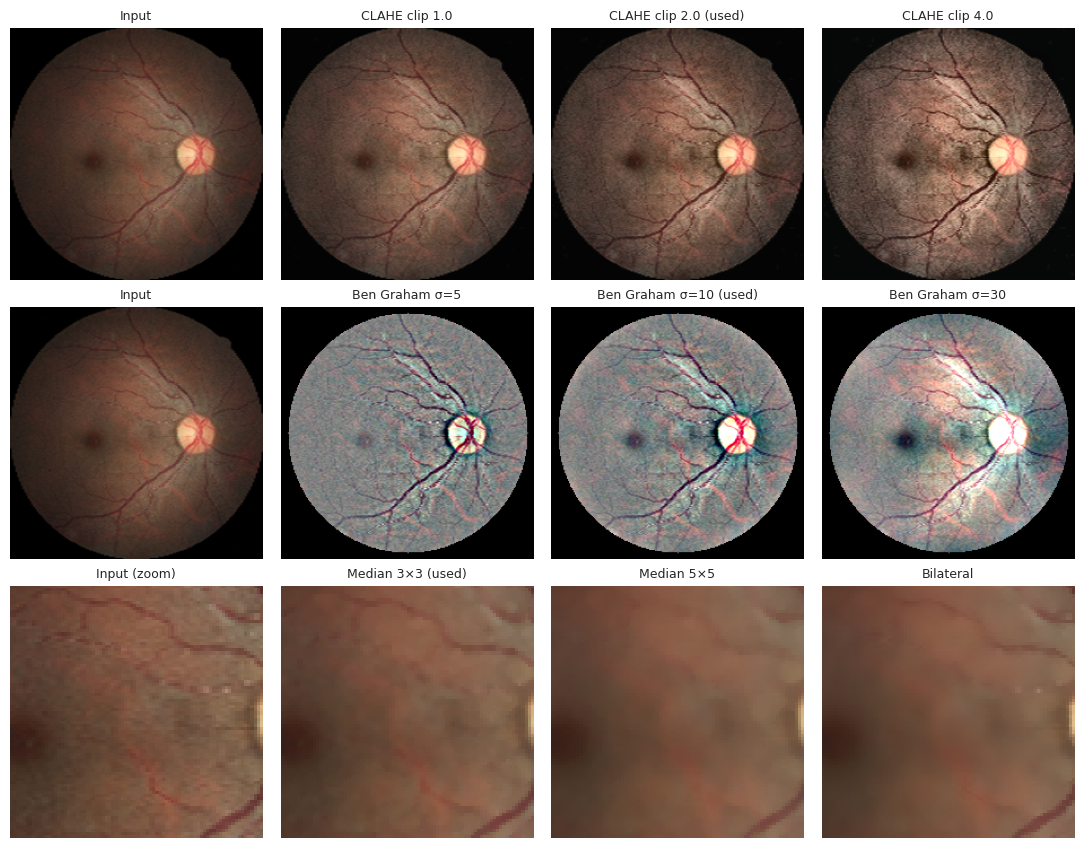

In [4]:
base = pp.resize(pp.crop_black_border(load(example["path"])), cfg["image"]["size"])

def row(ax_row, images, titles):
    for ax, im, t in zip(ax_row, images, titles):
        ax.imshow(im); ax.set_title(t, fontsize=9); ax.axis("off")

fig, axes = plt.subplots(3, 4, figsize=(11, 8.6))
row(axes[0], [base] + [pp.apply_clahe(base, c) for c in (1.0, 2.0, 4.0)],
    ["Input", "CLAHE clip 1.0", "CLAHE clip 2.0 (used)", "CLAHE clip 4.0"])
row(axes[1], [base] + [pp.circular_mask(pp.ben_graham(base, s)) for s in (5, 10, 30)],
    ["Input", "Ben Graham σ=5", "Ben Graham σ=10 (used)", "Ben Graham σ=30"])
crop = lambda im: im[70:150, 70:150]
row(axes[2], [crop(base), crop(pp.denoise(base, "median", 3)), crop(pp.denoise(base, "median", 5)),
              crop(pp.denoise(base, "bilateral", 3))],
    ["Input (zoom)", "Median 3×3 (used)", "Median 5×5", "Bilateral"])
plt.tight_layout(); plt.savefig(FIG / "preprocessing_parameters.png", dpi=200, bbox_inches="tight"); plt.show()

## 4. Worst-quality images

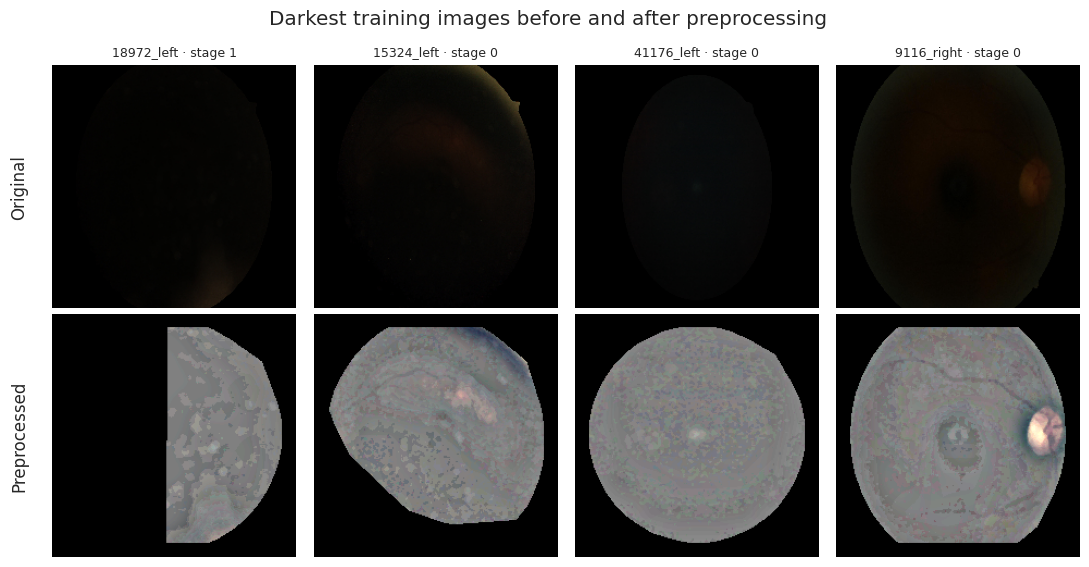

In [5]:
sample = train.sample(min(1500, len(train)), random_state=cfg["seed"]).copy()
sample["brightness"] = [pp.image_quality_metrics(load(p))["brightness"] for p in sample["path"]]
dark = sample.nsmallest(4, "brightness")
fig, axes = plt.subplots(2, 4, figsize=(11, 5.8))
for j, (_, r) in enumerate(dark.iterrows()):
    img = load(r["path"])
    axes[0, j].imshow(img); axes[0, j].set_title(f"{r['image_id']} · stage {r['label']}", fontsize=9)
    axes[1, j].imshow(pp.preprocess(img, cfg))
    for ax in axes[:, j]: ax.axis("off")
axes[0, 0].text(-0.1, 0.5, "Original", transform=axes[0, 0].transAxes, rotation=90, va="center", ha="right")
axes[1, 0].text(-0.1, 0.5, "Preprocessed", transform=axes[1, 0].transAxes, rotation=90, va="center", ha="right")
plt.suptitle("Darkest training images before and after preprocessing")
plt.tight_layout(); plt.savefig(FIG / "preprocessing_dark_images.png", dpi=200, bbox_inches="tight"); plt.show()

## 5. Quantitative effect

Measured on 500 random training images at three points: resized original, after CLAHE, and final output.
- **RMS contrast** (std of grey levels in the retina): higher means more visible detail
- **Entropy**: information content of the grey histogram
- **Sharpness** (Laplacian variance): strength of edges such as vessels and lesion borders

All measures are taken inside the retina only, so the retina/background edge is not counted as detail.
- **Brightness spread across images**: std of the mean brightness between images. Lower means the images are more consistent, which makes learning easier.

,rms_contrast,entropy,sharpness,brightness_spread
version,,,,
Original (resized),21.68,6.19,231.23,37.42
After CLAHE,24.85,6.49,157.86,32.16
Final pipeline,46.54,7.31,2268.27,2.84


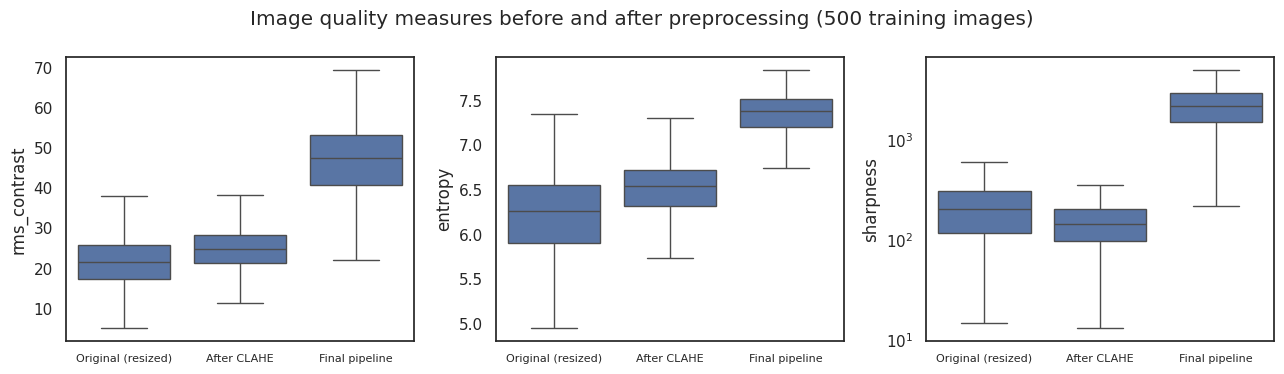

In [6]:
rows = []
cfg_clahe = copy.deepcopy(cfg); cfg_clahe["preprocessing"]["ben_graham"] = False
for p in train.sample(min(500, len(train)), random_state=cfg["seed"])["path"]:
    img = load(p)
    versions = {
        "Original (resized)": pp.resize(img, cfg["image"]["size"]),
        "After CLAHE": pp.preprocess(img, cfg_clahe),
        "Final pipeline": pp.preprocess(img, cfg),
    }
    for stage, im in versions.items():
        m = pp.image_quality_metrics(im)
        rows.append({"version": stage, **m})
q = pd.DataFrame(rows)

summary = q.groupby("version", sort=False).agg(
    rms_contrast=("rms_contrast", "mean"), entropy=("entropy", "mean"),
    sharpness=("sharpness", "mean"), brightness_spread=("brightness", "std")).round(2)
P["metrics_dir"].mkdir(parents=True, exist_ok=True)
summary.to_csv(P["metrics_dir"] / "preprocessing_quality.csv")
display(summary)

fig, axes = plt.subplots(1, 3, figsize=(13, 3.8))
for ax, metric in zip(axes, ["rms_contrast", "entropy", "sharpness"]):
    sns.boxplot(data=q, x="version", y=metric, ax=ax, showfliers=False)
    ax.set_xlabel(""); ax.tick_params(axis="x", labelsize=8)
    if metric == "sharpness": ax.set_yscale("log")
plt.suptitle("Image quality measures before and after preprocessing (500 training images)")
plt.tight_layout(); plt.savefig(FIG / "preprocessing_quality.png", dpi=200, bbox_inches="tight"); plt.show()

## Summary

Figures: `preprocessing_steps.png`, `preprocessing_per_stage.png`, `preprocessing_parameters.png`, `preprocessing_dark_images.png`, `preprocessing_quality.png`. Metrics: `outputs/metrics/preprocessing_quality.csv`.

The pipeline is applied identically in training, evaluation and the web API, and every step can be toggled in `configs/config.yaml`, which makes the raw vs preprocessed ablation in the training phase a one-line change.